In [94]:
# Instalar bibliotecas
import sys
import subprocess

required_packages = ["pandas", "glob2", "openpyxl", "rich", "missingno", "matplotlib", "scikit-learn", "seaborn"]

for package in required_packages:
    try:
        __import__(package if package != "glob2" else "glob")
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

In [95]:
# Importar Bibliotecas
import pandas as pd
import numpy as np
import glob
import os
import unicodedata
import pickle
import json
import time
from rich.logging import RichHandler
import logging
from functools import reduce
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [96]:
# Configuración logging
logging.basicConfig(
    level=logging.INFO,
    handlers=[RichHandler()],
    format="%(message)s"
)

log = logging.getLogger("rich")

In [97]:
# Cargar datos
log.info("Buscando archivos Excel en la carpeta 'datos/'...")

files = glob.glob("datos/*.xlsx")

if files:
    log.info(f"Se encontraron {len(files)} archivos")
else:
    log.warning("No se encontraron archivos .xlsx en la carpeta 'datos/'")

[01/31/26 21:59:02] INFO     Buscando archivos Excel en la carpeta 'datos/'...                      ]8;id=275476;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\2715900649.py\2715900649.py]8;;\:]8;id=128264;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\2715900649.py#2\2]8;;\

                    INFO     Se encontraron 12 archivos                                             ]8;id=717480;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\2715900649.py\2715900649.py]8;;\:]8;id=974550;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\2715900649.py#7\7]8;;\

In [98]:
def load_and_melt(filepath, value_name):
    df = pd.read_excel(filepath)
    
    # Normalizar nombre de fecha
    if 'Fecha' not in df.columns:
        df.columns = ['Fecha'] + list(df.columns[1:])
    
    df_long = df.melt(
        id_vars=['Fecha'],
        var_name='station',
        value_name=value_name
    )
    
    return df_long

In [99]:
file_map = {
    'CO.xlsx': 'CO',
    'IUV.xlsx': 'UV_Index',
    'LLU.xlsx': 'Precipitation',
    'NO2.xlsx': 'NO2',
    'O3.xlsx': 'O3',
    'PM10.xlsx': 'PM10',
    'PM2.5.xlsx': 'PM2.5',
    'PRE.xlsx': 'Pressure',
    'RS.xlsx': 'Solar_Radiation',
    'SO2.xlsx': 'SO2',
    'TMP.xlsx': 'Temperature',
    'VEL.xlsx': 'Wind_Velocity'
}

In [100]:
def load_and_melt(filepath, value_name):
    df = pd.read_excel(filepath)
    
    if 'Fecha' not in df.columns:
        df.columns = ['Fecha'] + list(df.columns[1:])
    
    # Forzar formato día/mes/año
    df['Fecha'] = pd.to_datetime(
        df['Fecha'], 
        dayfirst=True, 
        errors='coerce'
    )
    
    df_long = df.melt(
        id_vars=['Fecha'],
        var_name='station',
        value_name=value_name
    )
    
    return df_long

In [101]:
# PASO 1 y 2: Cargar, Normalizar y Consolidar datos
log.info("Iniciando carga y consolidacion de archivos...")

# Mapeo manual para normalizar nombres de estaciones
STATION_NAME_MAP = {
    'BELISARIO': 'BELISARIO',
    'Belisario': 'BELISARIO',
    'CARAPUNGO': 'CARAPUNGO',
    'Carapungo': 'CARAPUNGO',
    'CENTRO': 'CENTRO',
    'Centro': 'CENTRO',
    'COTOCOLLAO': 'COTOCOLLAO',
    'Cotocollao': 'COTOCOLLAO',
    'EL CAMAL': 'EL CAMAL',
    'ElCamal': 'EL CAMAL',
    'GUAMANI': 'GUAMANI',
    'Guamani': 'GUAMANI',
    'Guamaní': 'GUAMANI',
    'JIPIJAPA': 'JIPIJAPA',
    'Jipijapa': 'JIPIJAPA',
    'LOS CHILLOS': 'LOS CHILLOS',
    'LosChillos': 'LOS CHILLOS',
    'SAN ANTONIO': 'SAN ANTONIO',
    'SanAntonio': 'SAN ANTONIO',
    'TUMBACO': 'TUMBACO',
    'Tumbaco': 'TUMBACO'
}

def normalize_station_name(name):
    """Normaliza nombres usando mapeo manual"""
    name_str = str(name).strip()
    return STATION_NAME_MAP.get(name_str, name_str.upper())

# Cargar y normalizar cada archivo
dfs_long = []

for f in files:
    fname = os.path.basename(f)
    if fname in file_map:
        var_name = file_map[fname]
        df_long = load_and_melt(f, var_name)
        
        # Normalizar nombres de estaciones inmediatamente
        df_long['station'] = df_long['station'].apply(normalize_station_name)
        
        dfs_long.append(df_long)
        log.info(f"  Cargado y normalizado: {fname} -> {var_name}")

# Verificar estaciones unicas despues de normalizacion
all_stations = set()
for df in dfs_long:
    all_stations.update(df['station'].unique())
log.info(f"Estaciones unicas normalizadas: {len(all_stations)}")
for station in sorted(all_stations):
    log.info(f"  - {station}")

# Consolidar todos los DataFrames
df_master = reduce(
    lambda left, right: pd.merge(left, right, on=['Fecha','station'], how='outer'),
    dfs_long
)

df_master['date'] = pd.to_datetime(df_master['Fecha'], dayfirst=True, errors='coerce')

log.info(f"Consolidacion completada: {df_master.shape[0]:,} registros, {df_master.shape[1]} columnas")
log.info(f"Estaciones en dataset consolidado: {df_master['station'].nunique()}")

df_master.head()

                    INFO     Iniciando carga y consolidacion de archivos...                          ]8;id=568792;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\766066354.py\766066354.py]8;;\:]8;id=569314;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\766066354.py#2\2]8;;\

[01/31/26 21:59:12] INFO       Cargado y normalizado: CO.xlsx -> CO                                 ]8;id=726201;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\766066354.py\766066354.py]8;;\:]8;id=710013;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\766066354.py#47\47]8;;\

C:\Users\david\AppData\Local\Temp\ipykernel_29156\3498749953.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(


[01/31/26 21:59:14] INFO       Cargado y normalizado: IUV.xlsx -> UV_Index                          ]8;id=125066;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\766066354.py\766066354.py]8;;\:]8;id=575961;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\766066354.py#47\47]8;;\

                    INFO       Cargado y normalizado: LLU.xlsx -> Precipitation                     ]8;id=130738;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\766066354.py\766066354.py]8;;\:]8;id=800286;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\766066354.py#47\47]8;;\

...

                    INFO       - SAN ANTONIO                                                        ]8;id=886422;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\766066354.py\766066354.py]8;;\:]8;id=15615;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\766066354.py#55\55]8;;\

                    INFO       - TUMBACO                                                            ]8;id=302179;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\766066354.py\766066354.py]8;;\:]8;id=986659;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\766066354.py#55\55]8;;\

[01/31/26 22:03:06] INFO     Consolidacion completada: 1,809,086 registros, 15 columnas             ]8;id=429368;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\766066354.py\766066354.py]8;;\:]8;id=610841;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\766066354.py#65\65]8;;\

                    INFO     Estaciones en dataset consolidado: 10                                  ]8;id=398228;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\766066354.py\766066354.py]8;;\:]8;id=536595;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\766066354.py#66\66]8;;\

,Fecha,station,CO,UV_Index,Precipitation,NO2,O3,PM10,PM2.5,Pressure,Solar_Radiation,SO2,Temperature,Wind_Velocity,date
0,NaT,JIPIJAPA,NaN,IUV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
1,2004-01-01,BELISARIO,NaN,NaN,NaN,NaN,42.14,NaN,NaN,716.95,NaN,NaN,9.93,0.52,2004-01-01
2,2004-01-01,CARAPUNGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,721.05,NaN,NaN,12.73,NaN,2004-01-01
3,2004-01-01,CENTRO,NaN,NaN,NaN,121.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2004-01-01
4,2004-01-01,COTOCOLLAO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,734.47,NaN,NaN,10.41,0.44,2004-01-01


In [102]:
df_master[['date']].describe()
df_master['date'].isna().sum()

np.int64(1)

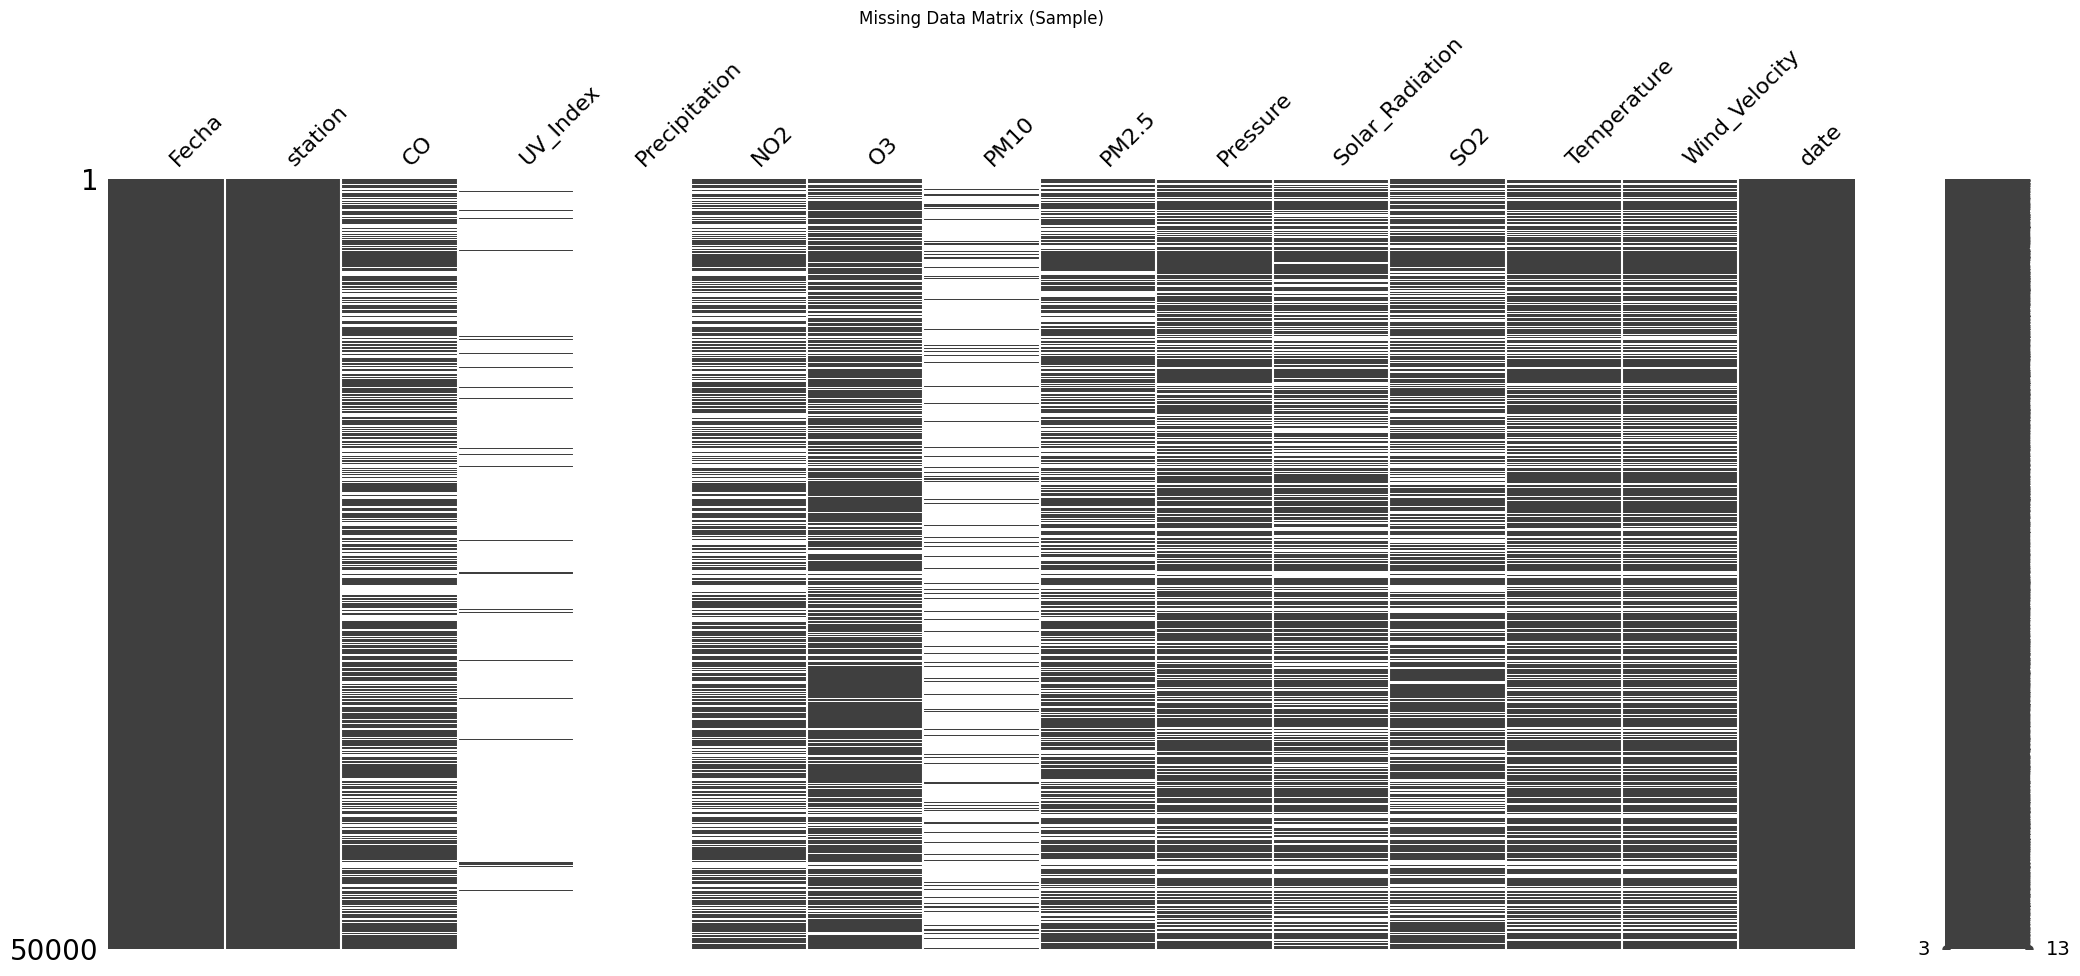

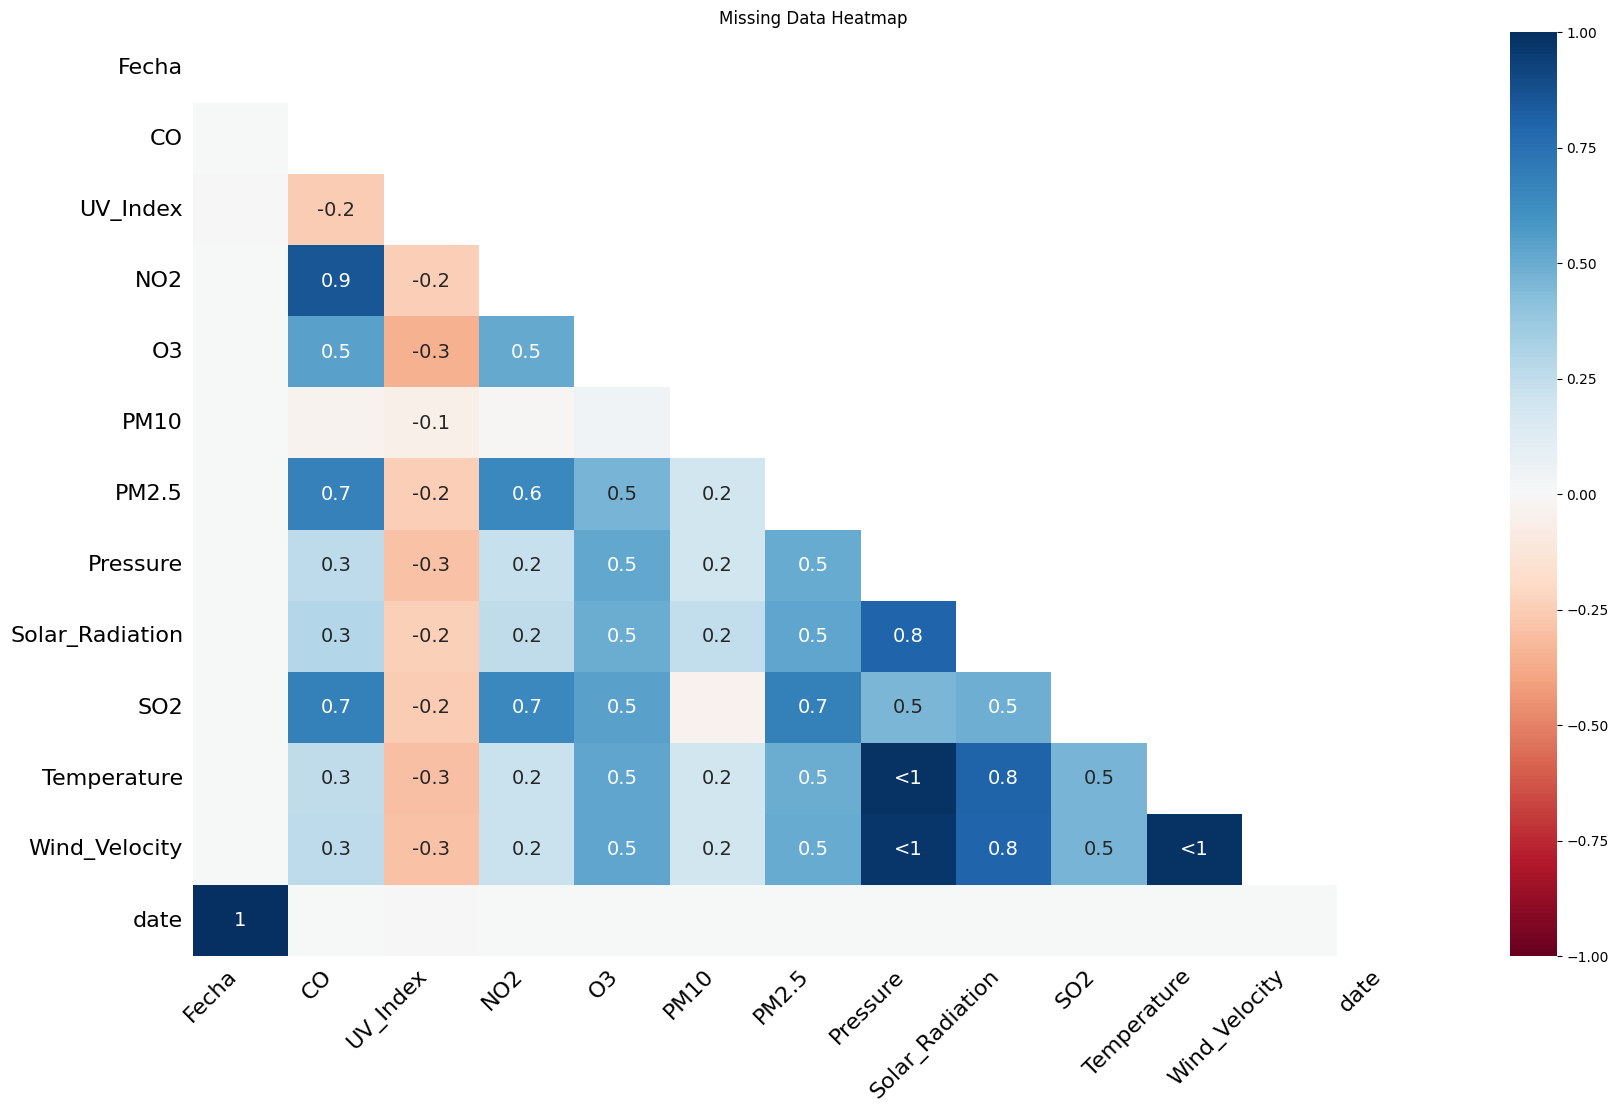

In [103]:
msno.matrix(df_master.sample(50000))  # sample para que no sea gigante
plt.title("Missing Data Matrix (Sample)")
plt.show()

msno.heatmap(df_master)
plt.title("Missing Data Heatmap")
plt.show()

In [104]:
missing_pct = df_master.isna().mean().sort_values(ascending=False)
missing_pct

Precipitation      1.000000e+00
UV_Index           9.669535e-01
PM10               8.979905e-01
Solar_Radiation    3.709249e-01
NO2                3.678852e-01
PM2.5              3.633951e-01
CO                 3.509811e-01
SO2                3.457857e-01
Wind_Velocity      2.810552e-01
Pressure           2.798806e-01
Temperature        2.773450e-01
O3                 2.156747e-01
Fecha              5.527653e-07
date               5.527653e-07
station            0.000000e+00
dtype: float64

In [105]:
df_imputed = df_master.copy()

num_cols = [
    'CO','UV_Index','Precipitation','NO2','O3',
    'PM10','PM2.5','Pressure','Solar_Radiation',
    'SO2','Temperature','Wind_Velocity'
]

# Eliminar filas sin fecha (CRÍTICO)
df_imputed = df_imputed.dropna(subset=['date'])

# Forzar columnas numéricas
for col in num_cols:
    df_imputed[col] = pd.to_numeric(df_imputed[col], errors='coerce')

# Procesar cada estación por separado
df_list = []

for station in df_imputed['station'].unique():
    # Filtrar por estación
    df_station = df_imputed[df_imputed['station'] == station].copy()
    
    # Ordenar por fecha y establecer como índice
    df_station = df_station.sort_values('date').set_index('date')
    
    # Interpolar
    df_station[num_cols] = df_station[num_cols].interpolate(method='time')
    df_station[num_cols] = df_station[num_cols].ffill().bfill()
    
    # Reset index y añadir a la lista
    df_station = df_station.reset_index()
    df_list.append(df_station)

# Concatenar todas las estaciones
df_imputed = pd.concat(df_list, ignore_index=True)

# Verificar que station se mantuvo
print(f"Columnas en df_imputed: {list(df_imputed.columns)}")
print(f"Estaciones unicas: {df_imputed['station'].nunique()}")
print(f"Total de registros: {len(df_imputed):,}")

# Verificar missing final
df_imputed.isna().mean().sort_values(ascending=False)

Columnas en df_imputed: ['date', 'Fecha', 'station', 'CO', 'UV_Index', 'Precipitation', 'NO2', 'O3', 'PM10', 'PM2.5', 'Pressure', 'Solar_Radiation', 'SO2', 'Temperature', 'Wind_Velocity']
Estaciones unicas: 10
Total de registros: 1,809,085


Precipitation      1.000000
UV_Index           0.959474
PM10               0.680174
NO2                0.147135
CO                 0.147135
SO2                0.147135
PM2.5              0.040526
Pressure           0.040526
Solar_Radiation    0.040526
Temperature        0.040526
O3                 0.040526
Wind_Velocity      0.040526
Fecha              0.000000
station            0.000000
date               0.000000
dtype: float64

In [106]:
# PASO 3: Agregacion diaria (horaria -> diaria)
log.info("Creando agregacion diaria...")

df_daily = df_imputed.groupby([pd.Grouper(key='date', freq='D'), 'station']).agg({
    'PM2.5': ['mean', 'std', 'min', 'max'],
    'Temperature': ['mean', 'min', 'max'],
    'Wind_Velocity': 'mean',
    'Precipitation': 'sum',
    'CO': 'mean',
    'NO2': 'mean',
    'O3': 'mean',
    'PM10': 'mean'
}).reset_index()

# Aplanar nombres de columnas
df_daily.columns = ['_'.join(col).strip('_') if col[1] else col[0] for col in df_daily.columns.values]
df_daily = df_daily.rename(columns={'date': 'Date_time'})

log.info(f"Agregacion diaria: {len(df_daily):,} registros")
log.info(f"Rango: {df_daily['Date_time'].min()} -> {df_daily['Date_time'].max()}")

df_daily.head()

[01/31/26 22:03:23] INFO     Creando agregacion diaria...                                           ]8;id=575675;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3482401753.py\3482401753.py]8;;\:]8;id=976821;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3482401753.py#2\2]8;;\

[01/31/26 22:03:26] INFO     Agregacion diaria: 75,388 registros                                   ]8;id=976606;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3482401753.py\3482401753.py]8;;\:]8;id=315860;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3482401753.py#19\19]8;;\

                    INFO     Rango: 2004-01-01 00:00:00 -> 2025-12-31 00:00:00                     ]8;id=360296;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3482401753.py\3482401753.py]8;;\:]8;id=783912;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3482401753.py#20\20]8;;\

,Date_time,station,PM2.5_mean,PM2.5_std,PM2.5_min,PM2.5_max,Temperature_mean,Temperature_min,Temperature_max,Wind_Velocity_mean,Precipitation_sum,CO_mean,NO2_mean,O3_mean,PM10_mean
0,2004-01-01,BELISARIO,27.35,0.0,27.35,27.35,14.010417,8.63,19.39,2.453750,0.0,4.510000,4.130000,64.025000,NaN
1,2004-01-01,CARAPUNGO,0.00,0.0,0.00,0.00,16.443333,11.64,23.59,3.616667,0.0,1.990000,15.250000,43.310000,52.14
2,2004-01-01,CENTRO,16.00,0.0,16.00,16.00,16.860000,16.86,16.86,1.760000,0.0,3.008333,23.655417,97.010000,NaN
3,2004-01-01,COTOCOLLAO,0.00,0.0,0.00,0.00,14.505417,9.44,21.88,1.190417,0.0,1.790000,22.210000,60.770000,NaN
4,2004-01-01,EL CAMAL,24.73,0.0,24.73,24.73,15.505000,11.08,21.39,2.521667,0.0,1.113750,16.527917,37.132917,NaN


In [107]:
# PASO 4: Agregacion mensual (para forecast 5-10 años)
log.info("Creando agregacion mensual...")

df_monthly = df_imputed.copy()
df_monthly['year_month'] = df_monthly['date'].dt.to_period('M')

df_monthly = df_monthly.groupby(['year_month', 'station']).agg({
    'PM2.5': ['mean', 'std', 'min', 'max'],
    'Temperature': ['mean', 'min', 'max'],
    'Wind_Velocity': 'mean',
    'Precipitation': 'sum',
    'CO': 'mean',
    'NO2': 'mean',
    'O3': 'mean'
}).reset_index()

df_monthly.columns = ['_'.join(col).strip('_') if col[1] else col[0] for col in df_monthly.columns.values]
df_monthly['Date_time'] = df_monthly['year_month'].dt.to_timestamp()

log.info(f"Agregacion mensual: {len(df_monthly):,} registros")
log.info(f"Meses unicos: {df_monthly['Date_time'].nunique()}")

df_monthly.head()

                    INFO     Creando agregacion mensual...                                          ]8;id=379991;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3028583481.py\3028583481.py]8;;\:]8;id=7896;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3028583481.py#2\2]8;;\

[01/31/26 22:03:28] INFO     Agregacion mensual: 2,477 registros                                   ]8;id=39048;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3028583481.py\3028583481.py]8;;\:]8;id=791702;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3028583481.py#20\20]8;;\

[01/31/26 22:03:29] INFO     Meses unicos: 264                                                     ]8;id=145120;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3028583481.py\3028583481.py]8;;\:]8;id=454066;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3028583481.py#21\21]8;;\

,year_month,station,PM2.5_mean,PM2.5_std,PM2.5_min,PM2.5_max,Temperature_mean,Temperature_min,Temperature_max,Wind_Velocity_mean,Precipitation_sum,CO_mean,NO2_mean,O3_mean,Date_time
0,2004-01,BELISARIO,27.35,0.0,27.35,27.35,12.679012,5.29,19.95,1.742392,0.0,4.263152,4.130000,57.502829,2004-01-01
1,2004-01,CARAPUNGO,0.00,0.0,0.00,0.00,14.481405,5.74,24.07,1.946526,0.0,1.990000,15.250000,43.310000,2004-01-01
2,2004-01,CENTRO,16.00,0.0,16.00,16.00,16.860000,16.86,16.86,1.760000,0.0,3.492198,43.150766,97.010000,2004-01-01
3,2004-01,COTOCOLLAO,0.00,0.0,0.00,0.00,13.340349,5.47,22.40,1.158259,0.0,1.790000,22.210000,60.770000,2004-01-01
4,2004-01,EL CAMAL,24.73,0.0,24.73,24.73,13.539852,6.12,21.45,1.895444,0.0,1.335531,29.443763,31.437164,2004-01-01


In [108]:
# PASO 5: Crear features temporales
log.info("Generando features temporales...")

datasets = [
    ('diaria', df_daily),
    ('mensual', df_monthly)
]

for name, df in datasets:
    date_col = 'Date_time'
    
    # Features basicas de tiempo
    df['year'] = df[date_col].dt.year
    df['month'] = df[date_col].dt.month
    df['day_of_week'] = df[date_col].dt.dayofweek
    df['quarter'] = df[date_col].dt.quarter
    df['day_of_year'] = df[date_col].dt.dayofyear
    
    # Features ciclicas (capturan estacionalidad)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    
    # Feature numerica para regresion
    df['days_since_start'] = (df[date_col] - df[date_col].min()).dt.days
    
    log.info(f"  Dataset {name}: {len(df.columns)} columnas totales")

log.info("Features temporales creadas")

                    INFO     Generando features temporales...                                       ]8;id=828572;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3147340023.py\3147340023.py]8;;\:]8;id=52158;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3147340023.py#2\2]8;;\

                    INFO       Dataset diaria: 23 columnas totales                                 ]8;id=563258;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3147340023.py\3147340023.py]8;;\:]8;id=557876;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3147340023.py#26\26]8;;\

                    INFO       Dataset mensual: 23 columnas totales                                ]8;id=495538;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3147340023.py\3147340023.py]8;;\:]8;id=885041;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3147340023.py#26\26]8;;\

                    INFO     Features temporales creadas                                           ]8;id=331411;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3147340023.py\3147340023.py]8;;\:]8;id=116022;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3147340023.py#28\28]8;;\

In [109]:
# PASO 6: Crear dataset agregado ciudad (promedio multi-estacion)
log.info("Creando dataset agregado de ciudad (promedio de todas las estaciones)...")

df_city = df_daily.groupby('Date_time').agg({
    'PM2.5_mean': 'mean',
    'PM2.5_std': 'mean',
    'Temperature_mean': 'mean',
    'Wind_Velocity_mean': 'mean',
    'Precipitation_sum': 'sum',
    'CO_mean': 'mean',
    'NO2_mean': 'mean',
    'O3_mean': 'mean',
    'PM10_mean': 'mean',
    'month_sin': 'first',
    'month_cos': 'first',
    'days_since_start': 'first'
}).reset_index()

log.info(f"Dataset ciudad: {len(df_city):,} dias")
log.info(f"Periodo: {df_city['Date_time'].min().date()} -> {df_city['Date_time'].max().date()}")

df_city.head()

                    INFO     Creando dataset agregado de ciudad (promedio de todas las              ]8;id=403765;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3564746337.py\3564746337.py]8;;\:]8;id=171701;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3564746337.py#2\2]8;;\
                             estaciones)...                                                                        

                    INFO     Dataset ciudad: 8,036 dias                                            ]8;id=502886;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3564746337.py\3564746337.py]8;;\:]8;id=269982;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3564746337.py#19\19]8;;\

                    INFO     Periodo: 2004-01-01 -> 2025-12-31                                     ]8;id=631988;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3564746337.py\3564746337.py]8;;\:]8;id=282714;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3564746337.py#20\20]8;;\

,Date_time,PM2.5_mean,PM2.5_std,Temperature_mean,Wind_Velocity_mean,Precipitation_sum,CO_mean,NO2_mean,O3_mean,PM10_mean,month_sin,month_cos,days_since_start
0,2004-01-01,16.082222,0.0,15.788559,2.390185,0.0,1.920260,19.747917,47.441759,37.713333,0.5,0.866025,0
1,2004-01-02,16.082222,0.0,16.040547,2.329583,0.0,1.938438,19.306823,44.156528,37.713333,0.5,0.866025,1
2,2004-01-03,16.082222,0.0,15.318213,1.844861,0.0,1.999323,21.698802,42.975556,37.713333,0.5,0.866025,2
3,2004-01-04,16.082222,0.0,15.261659,1.855556,0.0,1.934687,19.946823,46.187176,37.713333,0.5,0.866025,3
4,2004-01-05,16.082222,0.0,14.830943,1.826111,0.0,2.011354,21.745625,46.800370,37.713333,0.5,0.866025,4


In [110]:
# PASO 7: Train/Test split temporal (80/20)
log.info("Dividiendo dataset en Train/Test...")

split_date = df_city['Date_time'].quantile(0.8)
train = df_city[df_city['Date_time'] < split_date].copy()
test = df_city[df_city['Date_time'] >= split_date].copy()

log.info(f"Train: {len(train):,} dias ({train['Date_time'].min().date()} -> {train['Date_time'].max().date()})")
log.info(f"Test:  {len(test):,} dias ({test['Date_time'].min().date()} -> {test['Date_time'].max().date()})")
log.info(f"Fecha de corte: {split_date.date()}")

                    INFO     Dividiendo dataset en Train/Test...                                    ]8;id=244871;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3579624166.py\3579624166.py]8;;\:]8;id=144;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3579624166.py#2\2]8;;\

                    INFO     Train: 6,428 dias (2004-01-01 -> 2021-08-06)                           ]8;id=426913;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3579624166.py\3579624166.py]8;;\:]8;id=333706;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3579624166.py#8\8]8;;\

                    INFO     Test:  1,608 dias (2021-08-07 -> 2025-12-31)                           ]8;id=108427;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3579624166.py\3579624166.py]8;;\:]8;id=324200;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3579624166.py#9\9]8;;\

                    INFO     Fecha de corte: 2021-08-07                                            ]8;id=331765;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3579624166.py\3579624166.py]8;;\:]8;id=228475;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3579624166.py#10\10]8;;\

In [111]:
# PASO 8: Preparar features (X) y target (y)
log.info("Preparando features y target para modelo...")

# Features seleccionadas (multivariable)
feature_cols = [
    'days_since_start',
    'Temperature_mean',
    'Wind_Velocity_mean',
    'Precipitation_sum',
    'month_sin',
    'month_cos'
]

X_train = train[feature_cols]
y_train = train['PM2.5_mean']

X_test = test[feature_cols]
y_test = test['PM2.5_mean']

log.info(f"X_train shape: {X_train.shape}")
log.info(f"X_test shape:  {X_test.shape}")
log.info(f"Features: {feature_cols}")

                    INFO     Preparando features y target para modelo...                            ]8;id=682618;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\2544634270.py\2544634270.py]8;;\:]8;id=572466;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\2544634270.py#2\2]8;;\

                    INFO     X_train shape: (6428, 6)                                              ]8;id=438602;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\2544634270.py\2544634270.py]8;;\:]8;id=968977;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\2544634270.py#20\20]8;;\

                    INFO     X_test shape:  (1608, 6)                                              ]8;id=257956;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\2544634270.py\2544634270.py]8;;\:]8;id=597730;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\2544634270.py#21\21]8;;\

                    INFO     Features: ['days_since_start', 'Temperature_mean',                    ]8;id=62366;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\2544634270.py\2544634270.py]8;;\:]8;id=53300;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\2544634270.py#22\22]8;;\
                             'Wind_Velocity_mean', 'Precipitation_sum', 'month_sin', 'month_cos']                  

In [112]:
# PASO 9: Crear features polinomiales (degree=2)
log.info("Generando features polinomiales (degree=2)...")

poly = PolynomialFeatures(degree=2, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

log.info(f"Features originales: {X_train.shape[1]}")
log.info(f"Features polinomiales: {X_train_poly.shape[1]}")
log.info(f"Incluye: terminos lineales, cuadraticos e interacciones")

                    INFO     Generando features polinomiales (degree=2)...                          ]8;id=935614;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\4100187912.py\4100187912.py]8;;\:]8;id=530581;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\4100187912.py#2\2]8;;\

                    INFO     Features originales: 6                                                 ]8;id=929747;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\4100187912.py\4100187912.py]8;;\:]8;id=771871;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\4100187912.py#8\8]8;;\

                    INFO     Features polinomiales: 28                                              ]8;id=611144;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\4100187912.py\4100187912.py]8;;\:]8;id=244983;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\4100187912.py#9\9]8;;\

                    INFO     Incluye: terminos lineales, cuadraticos e interacciones               ]8;id=900686;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\4100187912.py\4100187912.py]8;;\:]8;id=156196;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\4100187912.py#10\10]8;;\

In [113]:
# PASO 10: Escalado de features
log.info("Aplicando escalado a features polinomiales...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

log.info(f"Escalado aplicado: media=0, std=1")
log.info(f"Scaler guardado para reproducibilidad")

# Guardar scaler para uso futuro
with open('scaler_model1.pkl', 'wb') as f:
    pickle.dump(scaler, f)

                    INFO     Aplicando escalado a features polinomiales...                          ]8;id=704424;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\1567515665.py\1567515665.py]8;;\:]8;id=349635;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\1567515665.py#2\2]8;;\

                    INFO     Escalado aplicado: media=0, std=1                                      ]8;id=919837;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\1567515665.py\1567515665.py]8;;\:]8;id=546187;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\1567515665.py#8\8]8;;\

                    INFO     Scaler guardado para reproducibilidad                                  ]8;id=14741;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\1567515665.py\1567515665.py]8;;\:]8;id=85974;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\1567515665.py#9\9]8;;\

In [114]:
# PASO 11: Entrenar modelo de Regresion Lineal
log.info("Entrenando modelo de Regresion Cuadratica...")

start_time = time.time()
model_quad = LinearRegression()
model_quad.fit(X_train_scaled, y_train)
training_time = time.time() - start_time

log.info(f"Modelo entrenado en {training_time:.3f} segundos")
log.info(f"Coeficientes: {len(model_quad.coef_)} features")
log.info(f"Intercepto: {model_quad.intercept_:.4f}")

                    INFO     Entrenando modelo de Regresion Cuadratica...                           ]8;id=676738;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3198767363.py\3198767363.py]8;;\:]8;id=448312;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3198767363.py#2\2]8;;\

                    INFO     Modelo entrenado en 0.027 segundos                                     ]8;id=568480;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3198767363.py\3198767363.py]8;;\:]8;id=730900;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3198767363.py#9\9]8;;\

                    INFO     Coeficientes: 28 features                                             ]8;id=160312;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3198767363.py\3198767363.py]8;;\:]8;id=299057;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3198767363.py#10\10]8;;\

                    INFO     Intercepto: 17.6438                                                   ]8;id=584898;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3198767363.py\3198767363.py]8;;\:]8;id=395581;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3198767363.py#11\11]8;;\

In [115]:
# PASO 12: Generar predicciones
log.info("Generando predicciones...")

y_pred_train = model_quad.predict(X_train_scaled)
y_pred_test = model_quad.predict(X_test_scaled)

log.info(f"Train - Real: [{y_train.min():.2f}, {y_train.max():.2f}] | Pred: [{y_pred_train.min():.2f}, {y_pred_train.max():.2f}]")
log.info(f"Test  - Real: [{y_test.min():.2f}, {y_test.max():.2f}] | Pred: [{y_pred_test.min():.2f}, {y_pred_test.max():.2f}]")

                    INFO     Generando predicciones...                                              ]8;id=197701;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3705531652.py\3705531652.py]8;;\:]8;id=964552;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3705531652.py#2\2]8;;\

                    INFO     Train - Real: [5.04, 35.59] | Pred: [6.98, 23.45]                      ]8;id=733930;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3705531652.py\3705531652.py]8;;\:]8;id=569569;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3705531652.py#7\7]8;;\

                    INFO     Test  - Real: [5.79, 37.07] | Pred: [-1.07, 17.50]                     ]8;id=979210;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3705531652.py\3705531652.py]8;;\:]8;id=246003;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3705531652.py#8\8]8;;\

In [116]:
# PASO 13: Calcular metricas de evaluacion
log.info("Calculando metricas de evaluacion...")

metrics = {
    'train': {
        'MSE': mean_squared_error(y_train, y_pred_train),
        'RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'MAE': mean_absolute_error(y_train, y_pred_train),
        'R2': r2_score(y_train, y_pred_train)
    },
    'test': {
        'MSE': mean_squared_error(y_test, y_pred_test),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'MAE': mean_absolute_error(y_test, y_pred_test),
        'R2': r2_score(y_test, y_pred_test)
    }
}

print("\n" + "="*60)
print("METRICAS DEL MODELO 1: REGRESION CUADRATICA")
print("="*60)
print(f"\n{'Metrica':<10} {'Train':>12} {'Test':>12}")
print("-"*60)
for metric in ['MSE', 'RMSE', 'MAE', 'R2']:
    print(f"{metric:<10} {metrics['train'][metric]:>12.4f} {metrics['test'][metric]:>12.4f}")
print("="*60)

                    INFO     Calculando metricas de evaluacion...                                    ]8;id=310021;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\243852550.py\243852550.py]8;;\:]8;id=75682;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\243852550.py#2\2]8;;\


METRICAS DEL MODELO 1: REGRESION CUADRATICA

Metrica           Train         Test
------------------------------------------------------------
MSE              9.1305      74.8925
RMSE             3.0217       8.6540
MAE              2.3040       7.5185
R2               0.3888      -3.2855


                    INFO     Generando visualizacion: Timeline completo...                           ]8;id=398533;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\868743804.py\868743804.py]8;;\:]8;id=46131;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\868743804.py#2\2]8;;\

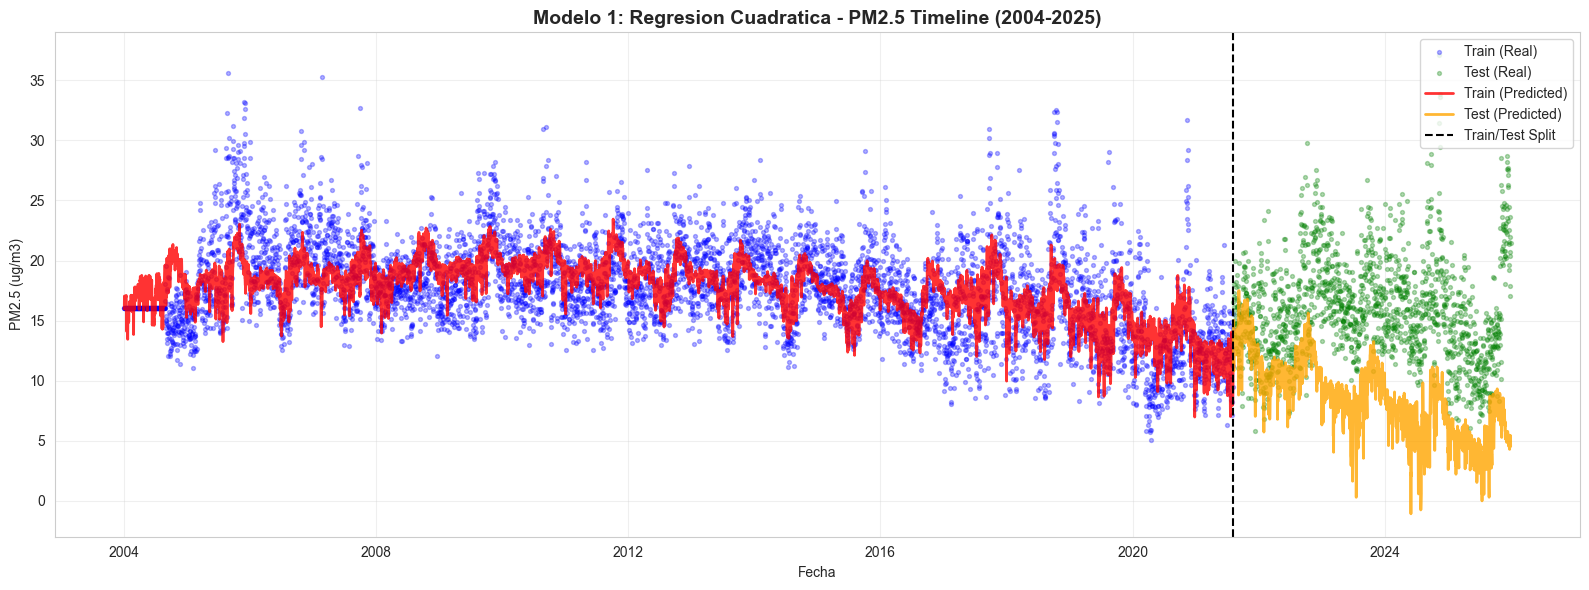

[01/31/26 22:03:32] INFO     Guardado: model1_timeline.png                                          ]8;id=752643;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\868743804.py\868743804.py]8;;\:]8;id=594469;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\868743804.py#22\22]8;;\

In [117]:
# PASO 14: Visualizacion 1 - Timeline completo
log.info("Generando visualizacion: Timeline completo...")

sns.set_style("whitegrid")
plt.figure(figsize=(16, 6))

plt.scatter(train['Date_time'], y_train, alpha=0.3, s=8, label='Train (Real)', color='blue')
plt.scatter(test['Date_time'], y_test, alpha=0.3, s=8, label='Test (Real)', color='green')
plt.plot(train['Date_time'], y_pred_train, color='red', label='Train (Predicted)', linewidth=2, alpha=0.8)
plt.plot(test['Date_time'], y_pred_test, color='orange', label='Test (Predicted)', linewidth=2, alpha=0.8)
plt.axvline(split_date, color='black', linestyle='--', linewidth=1.5, label='Train/Test Split')

plt.title('Modelo 1: Regresion Cuadratica - PM2.5 Timeline (2004-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('PM2.5 (ug/m3)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('model1_timeline.png', dpi=150)
plt.show()

log.info("Guardado: model1_timeline.png")

                    INFO     Generando visualizacion: Residual Plot...                               ]8;id=543277;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\440198764.py\440198764.py]8;;\:]8;id=570751;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\440198764.py#2\2]8;;\

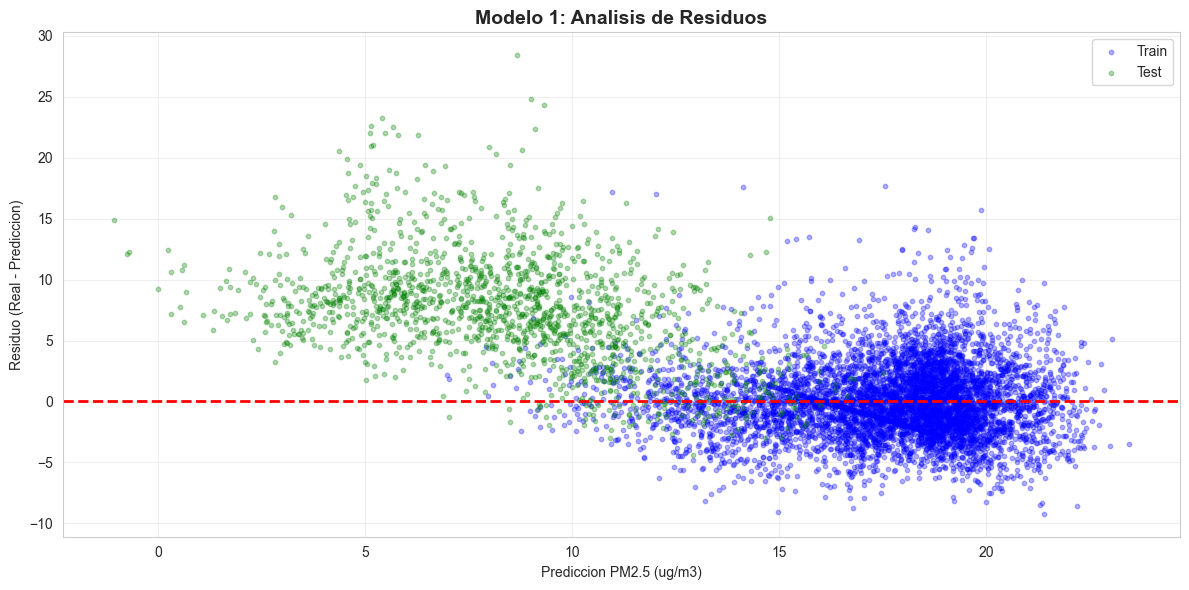

[01/31/26 22:03:33] INFO     Residuos centrados en 0 indican buen ajuste                            ]8;id=411823;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\440198764.py\440198764.py]8;;\:]8;id=328693;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\440198764.py#20\20]8;;\

In [118]:
# PASO 15: Visualizacion 2 - Residual Plot
log.info("Generando visualizacion: Residual Plot...")

residuals_train = y_train - y_pred_train
residuals_test = y_test - y_pred_test

plt.figure(figsize=(12, 6))
plt.scatter(y_pred_train, residuals_train, alpha=0.3, s=10, label='Train', color='blue')
plt.scatter(y_pred_test, residuals_test, alpha=0.3, s=10, label='Test', color='green')
plt.axhline(0, color='red', linestyle='--', linewidth=2)

plt.title('Modelo 1: Analisis de Residuos', fontsize=14, fontweight='bold')
plt.xlabel('Prediccion PM2.5 (ug/m3)')
plt.ylabel('Residuo (Real - Prediccion)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

log.info("Residuos centrados en 0 indican buen ajuste")

                    INFO     Generando visualizacion: Real vs Predicted...                           ]8;id=375124;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\554348750.py\554348750.py]8;;\:]8;id=67092;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\554348750.py#2\2]8;;\

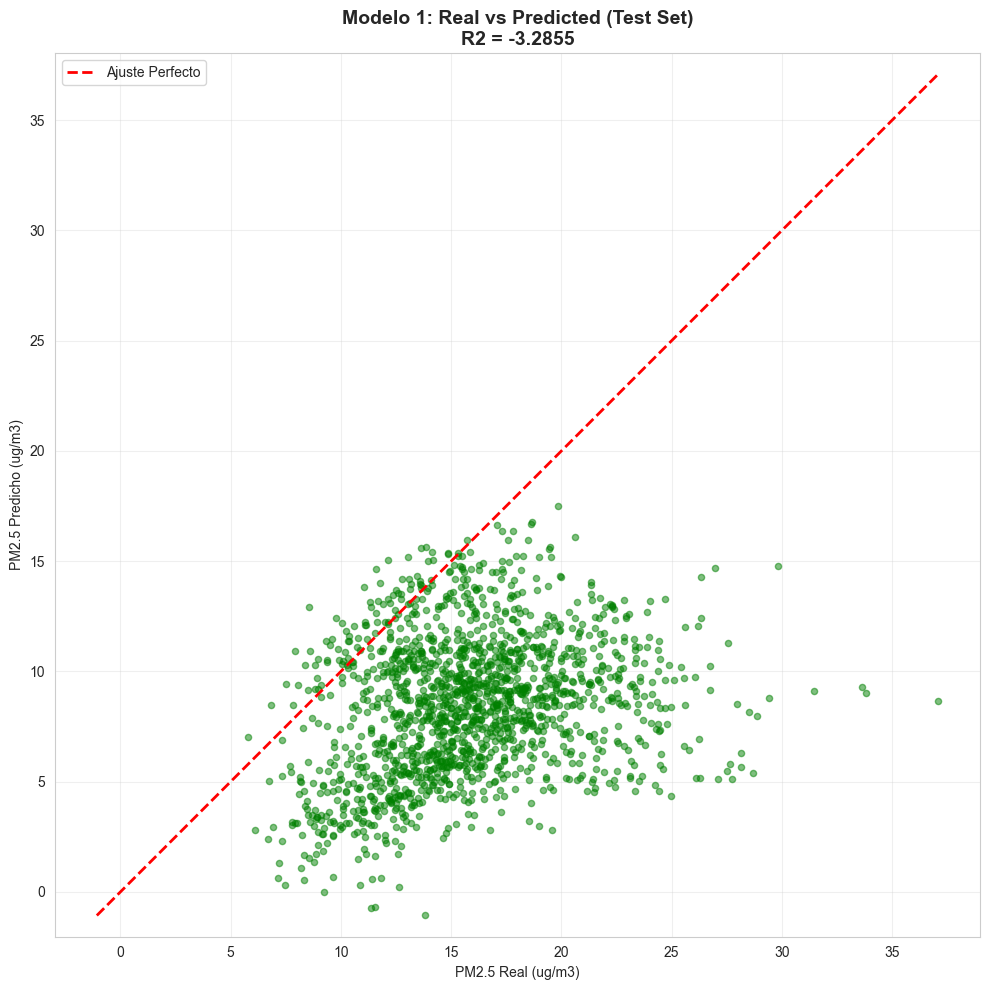

[01/31/26 22:03:35] INFO     Guardado: model1_scatter.png                                           ]8;id=894494;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\554348750.py\554348750.py]8;;\:]8;id=36339;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\554348750.py#22\22]8;;\

In [119]:
# PASO 16: Visualizacion 3 - Real vs Predicted
log.info("Generando visualizacion: Real vs Predicted...")

plt.figure(figsize=(10, 10))
plt.scatter(y_test, y_pred_test, alpha=0.5, s=20, color='green')

min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ajuste Perfecto')

plt.title(f'Modelo 1: Real vs Predicted (Test Set)\nR2 = {metrics["test"]["R2"]:.4f}', 
          fontsize=14, fontweight='bold')
plt.xlabel('PM2.5 Real (ug/m3)')
plt.ylabel('PM2.5 Predicho (ug/m3)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.savefig('model1_scatter.png', dpi=150)
plt.show()

log.info("Guardado: model1_scatter.png")

                    INFO     Generando visualizacion: Distribucion de errores...                      ]8;id=806243;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\86995909.py\86995909.py]8;;\:]8;id=876188;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\86995909.py#2\2]8;;\

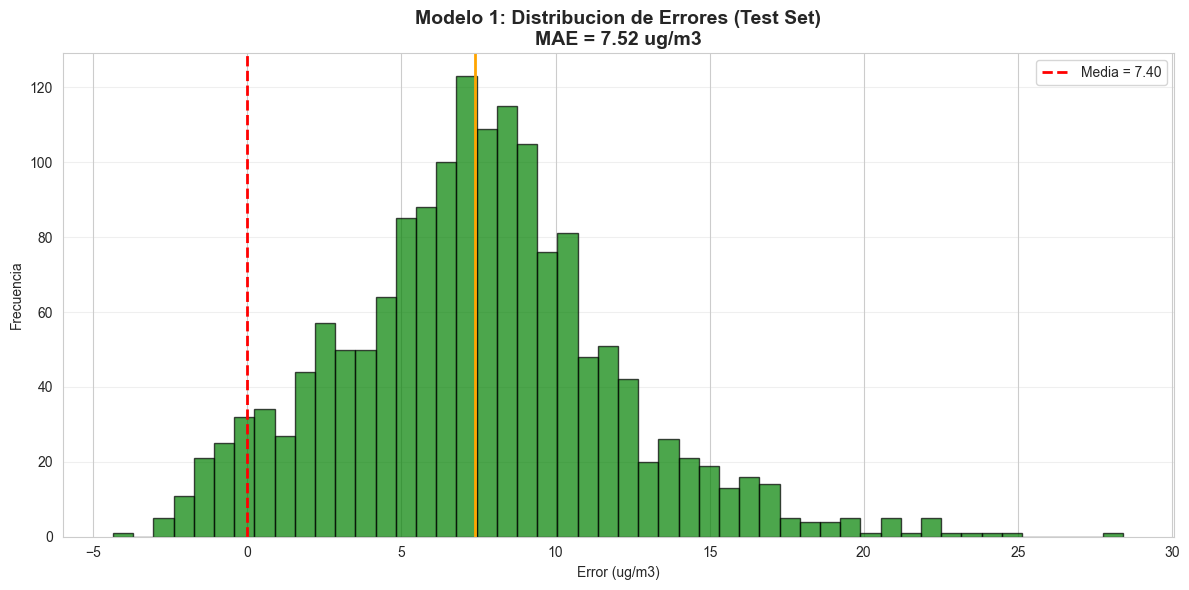

[01/31/26 22:03:36] INFO     Distribucion normal de errores indica supuestos de regresion validos    ]8;id=690445;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\86995909.py\86995909.py]8;;\:]8;id=158779;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\86995909.py#18\18]8;;\

In [120]:
# PASO 17: Visualizacion 4 - Distribucion de errores
log.info("Generando visualizacion: Distribucion de errores...")

plt.figure(figsize=(12, 6))
plt.hist(residuals_test, bins=50, alpha=0.7, color='green', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2, label=f'Media = {residuals_test.mean():.2f}')
plt.axvline(residuals_test.mean(), color='orange', linestyle='-', linewidth=2)

plt.title(f'Modelo 1: Distribucion de Errores (Test Set)\nMAE = {metrics["test"]["MAE"]:.2f} ug/m3', 
          fontsize=14, fontweight='bold')
plt.xlabel('Error (ug/m3)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

log.info("Distribucion normal de errores indica supuestos de regresion validos")

                    INFO     Analizando importancia de features...                                  ]8;id=753420;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\4262455548.py\4262455548.py]8;;\:]8;id=86373;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\4262455548.py#2\2]8;;\

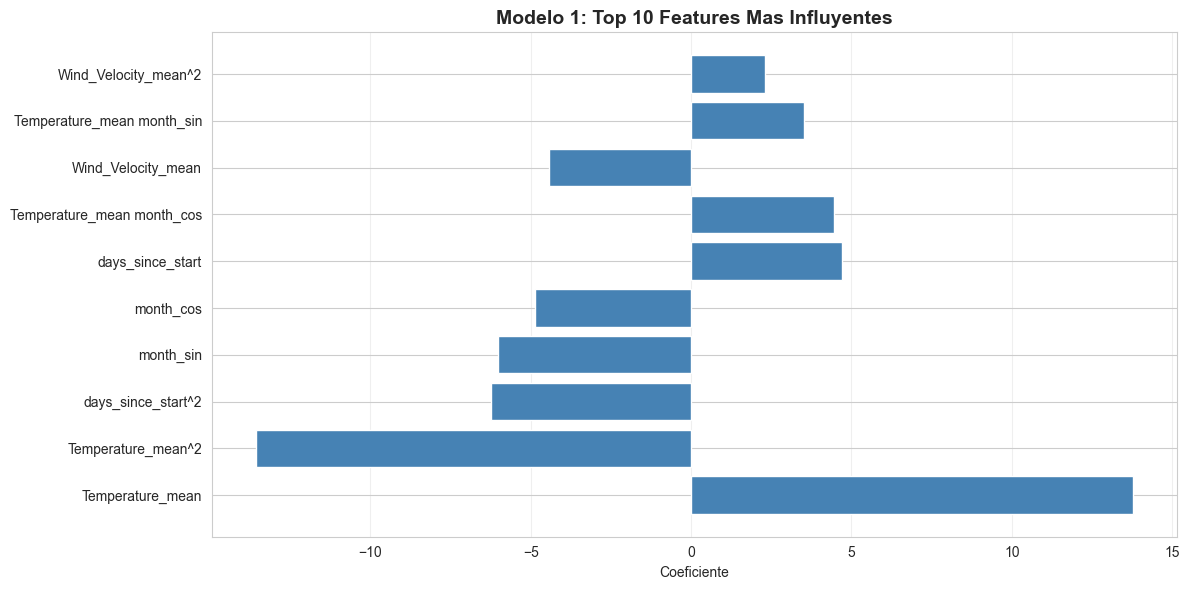

                    INFO     Feature mas influyente: Temperature_mean                              ]8;id=813977;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\4262455548.py\4262455548.py]8;;\:]8;id=724274;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\4262455548.py#26\26]8;;\

In [121]:
# PASO 18: Analisis de Feature Importance
log.info("Analizando importancia de features...")

feature_names = poly.get_feature_names_out(feature_cols)
coefficients = model_quad.coef_

# Crear DataFrame de coeficientes
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coeficiente': coefficients,
    'Abs_Coef': np.abs(coefficients)
}).sort_values('Abs_Coef', ascending=False)

# Top 10 features mas importantes
top_features = coef_df.head(10)

plt.figure(figsize=(12, 6))
plt.barh(range(len(top_features)), top_features['Coeficiente'], color='steelblue')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Coeficiente')
plt.title('Modelo 1: Top 10 Features Mas Influyentes', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

log.info(f"Feature mas influyente: {top_features.iloc[0]['Feature']}")

In [122]:
# PASO 19: Exportar resultados del modelo
log.info("Exportando resultados del Modelo 1...")

# Guardar modelo y transformadores
model1_artifacts = {
    'model': model_quad,
    'poly_transformer': poly,
    'scaler': scaler,
    'feature_columns': feature_cols
}

with open('model1_artifacts.pkl', 'wb') as f:
    pickle.dump(model1_artifacts, f)

# Guardar metricas en JSON
metrics_export = {
    'model_name': 'Modelo 1: Regresion Cuadratica Multivariable',
    'model_type': 'Polynomial Regression (degree=2)',
    'features': feature_cols,
    'n_polynomial_features': X_train_poly.shape[1],
    'metrics': metrics,
    'training_data_size': len(train),
    'test_data_size': len(test)
}

with open('model1_metrics.json', 'w') as f:
    json.dump(metrics_export, f, indent=2)

log.info("Guardado: model1_artifacts.pkl")
log.info("Guardado: model1_metrics.json")
log.info("Archivos listos para comparacion con otros modelos")

                    INFO     Exportando resultados del Modelo 1...                                  ]8;id=456429;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3637314873.py\3637314873.py]8;;\:]8;id=717900;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3637314873.py#2\2]8;;\

                    INFO     Guardado: model1_artifacts.pkl                                        ]8;id=198090;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3637314873.py\3637314873.py]8;;\:]8;id=975901;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3637314873.py#29\29]8;;\

                    INFO     Guardado: model1_metrics.json                                         ]8;id=27444;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3637314873.py\3637314873.py]8;;\:]8;id=884753;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3637314873.py#30\30]8;;\

                    INFO     Archivos listos para comparacion con otros modelos                    ]8;id=783312;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3637314873.py\3637314873.py]8;;\:]8;id=40792;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\3637314873.py#31\31]8;;\

In [125]:
# PASO 20: Summary Report - Modelo 1
log.info("="*60)
log.info("REPORTE FINAL - MODELO 1: REGRESION CUADRATICA")
log.info("="*60)

print(f"\nCONFIGURACION DEL MODELO:")
print(f"  - Tipo: Regresion Polinomial (degree=2)")
print(f"  - Features originales: {len(feature_cols)}")
print(f"  - Features polinomiales: {X_train_poly.shape[1]}")
print(f"  - Escalado: StandardScaler aplicado")

print(f"\nPERFORMANCE (TEST SET):")
print(f"  - RMSE: {metrics['test']['RMSE']:.2f} ug/m3")
print(f"  - MAE:  {metrics['test']['MAE']:.2f} ug/m3")
print(f"  - R2:   {metrics['test']['R2']:.4f}")

print(f"\nINTERPRETACION:")
if metrics['test']['R2'] > 0.7:
    print(f"  - Buen ajuste (R2 > 0.7)")
elif metrics['test']['R2'] > 0.5:
    print(f"  - Ajuste moderado (R2 > 0.5)")
else:
    print(f"  - Ajuste debil - considerar features adicionales")

print(f"\nENTREGABLES GENERADOS:")
print(f"  - Graficos: model1_timeline.png, model1_scatter.png")
print(f"  - Artefactos: model1_artifacts.pkl")
print(f"  - Metricas: model1_metrics.json")

print(f"\nPROXIMOS PASOS:")
print(f"  - Comparar con modelos ARIMA, LSTM, MLForecast")
print(f"  - Validar con datos futuros (2026+)")
print(f"  - Considerar mejoras: features adicionales, regularizacion")

log.info("="*60)
log.info("Modelo 1 completado exitosamente")
log.info("="*60)

[01/31/26 22:07:03] INFO     ============================================================           ]8;id=166520;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\2462877711.py\2462877711.py]8;;\:]8;id=405725;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\2462877711.py#2\2]8;;\

                    INFO     REPORTE FINAL - MODELO 1: REGRESION CUADRATICA                         ]8;id=375287;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\2462877711.py\2462877711.py]8;;\:]8;id=182592;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\2462877711.py#3\3]8;;\

                    INFO     ============================================================           ]8;id=98888;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\2462877711.py\2462877711.py]8;;\:]8;id=399308;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\2462877711.py#4\4]8;;\


CONFIGURACION DEL MODELO:
  - Tipo: Regresion Polinomial (degree=2)
  - Features originales: 6
  - Features polinomiales: 28
  - Escalado: StandardScaler aplicado

PERFORMANCE (TEST SET):
  - RMSE: 8.65 ug/m3
  - MAE:  7.52 ug/m3
  - R2:   -3.2855

INTERPRETACION:
  - Ajuste debil - considerar features adicionales

ENTREGABLES GENERADOS:
  - Graficos: model1_timeline.png, model1_scatter.png
  - Artefactos: model1_artifacts.pkl
  - Metricas: model1_metrics.json

PROXIMOS PASOS:
  - Comparar con modelos ARIMA, LSTM, MLForecast
  - Validar con datos futuros (2026+)
  - Considerar mejoras: features adicionales, regularizacion


                    INFO     ============================================================          ]8;id=513364;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\2462877711.py\2462877711.py]8;;\:]8;id=52510;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\2462877711.py#35\35]8;;\

                    INFO     Modelo 1 completado exitosamente                                      ]8;id=334431;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\2462877711.py\2462877711.py]8;;\:]8;id=958343;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\2462877711.py#36\36]8;;\

                    INFO     ============================================================          ]8;id=190217;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\2462877711.py\2462877711.py]8;;\:]8;id=174550;file://C:\Users\david\AppData\Local\Temp\ipykernel_29156\2462877711.py#37\37]8;;\